# Analyzing Public Perception of DeepSeek on Reddit: A Text-Based Exploration

# Introduction

The rise of DeepSeek and other large language models (LLMs) marks both a technological milestone and an opportunity to explore the geopolitical and cultural tensions in the global AI landscape. It is important to examine how predominantly English-speaking social media platforms, particularly Reddit, shape perceptions of AI models like DeepSeek (developed in China) and ChatGPT (developed in the U.S.). In this task, we ask the question: **What narratives emerge from Reddit communities’ discussions about DeepSeek, and how do these narratives reflect user perceptions and sentiment of AI innovation?**




# Overview
In this assignment, we will practice text analysis with the following guided tasks:

1) **Task 1**: Apply **K-means** clustering to identify hidden groups within the data

2) **Task 2**: Conduct **sentiment analysis** to examine user emotions toward "DeepSeek"

3) **Task 3**: Perform **topic modeling** to uncover latent topics regarding "DeepSeek"



# Data
Reddit offers an open and unfiltered platform where individuals share their perceptions about AI techniques, making it an ideal source of authentic data. We download subreddit posts on DeepSeek (r/DeepSeek_posts) from [arctic-shift](https://arctic-shift.photon-reddit.com/).

In [1]:
import os,datetime
import json, csv
import re
import pandas as pd
import numpy as np
from collections import Counter
import pprint

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.dates import DateFormatter

import warnings
warnings.filterwarnings('ignore')

In [2]:
import nltk
from nltk.corpus import words

nltk.download('words')
english_words = set(words.words())

[nltk_data] Downloading package words to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package words is already up-to-date!


# Exploratory Data Analysis

In [3]:
def load_data(data_file):
    """
    Load original data from jsonl file, clean the data, and convert to a dataframe
    """

    # Step 1: Read json file, store as list of dicts
    posts_lst = []
    with open(data_file, 'r') as file:
        for line in file:
            posts_lst.append(json.loads(line))

    # Step 2: Extract fields that contain key information
    fields_to_extract = ['permalink', 'created_utc', 'selftext', 'title']

    # Step 3: Store the extracted information in a Dataframe
    extracted_data = [{k: d[k] for k in fields_to_extract if k in d} for d in posts_lst]
    df = pd.DataFrame(extracted_data)

    # Step 4: Complete each field of the dataframe
    df['permalink'] = 'https://old.reddit.com' + df['permalink']
    # Convert the unix timestamp to readable date
    df['date'] = df['created_utc'].apply(lambda x: datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d'))
    del df['created_utc']

    # Step 5: Remove rows with missing values
    df.dropna(how = 'any', inplace=True)
    df = df[df['selftext'] != '[removed]']
    df.rename(columns={'selftext':'post'}, inplace=True)

    # Step 6: Convert dtype: object to string
    df = df.convert_dtypes()

    return df

In [4]:
def clean_text(text):
    '''
    Cleans the input text by removing URLs, HTML tags, mentions, hashtags,
    punctuation, special characters, newlines, and extra spaces.

    Input:
        text: a string containing raw text.
    Output:
        cleaned_text: a string with cleaned text.
    '''
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove mentions (@username) and hashtags (#hashtag)
    text = re.sub(r'[@#]\w+', '', text)
    # Remove punctuation and special characters, replace with space
    text = re.sub(r'[^\w\s]', ' ', text)
    # Replace newlines with spaces
    text = text.replace('\n', ' ')
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing spaces
    text = text.strip()

    # Remove non-English words
    text = ' '.join(word for word in text.split() if word.lower() in english_words)

    return text

In [5]:
# load and clean the post
df_post = load_data('r_DeepSeek_posts.jsonl')
df_post['post'] = df_post['post'].apply(lambda x: clean_text(x))
df_post.shape

(7051, 4)

In [6]:
df_post

,permalink,post,title,date
0,https://old.reddit.com/r/DeepSeek/comments/1do...,,What's the max tokens for deepseek-coder-v2?,2024-06-25
1,https://old.reddit.com/r/DeepSeek/comments/1eo...,Seriously super factual and level performance,DeepSeek Coder V2 is a beast!,2024-08-10
2,https://old.reddit.com/r/DeepSeek/comments/1fd...,anyone tried to get it working in Dev I m gett...,Integrating with Claude-Dev,2024-09-10
3,https://old.reddit.com/r/DeepSeek/comments/1fw...,I have a question that i cant seem to find yet...,How to simultaneously complete a LLMs workload...,2024-10-04
4,https://old.reddit.com/r/DeepSeek/comments/1gc...,I was chatting through coder but today upon a ...,What happened to Coder DeepSeek?,2024-10-26
...,...,...,...,...
7537,https://old.reddit.com/r/DeepSeek/comments/1ke...,,Qwen 235b already topping benchmarks and this ...,2025-05-03
7538,https://old.reddit.com/r/DeepSeek/comments/1ke...,I am sure that everyone here that more or less...,What types of output do bare Deepseek models p...,2025-05-03
7539,https://old.reddit.com/r/DeepSeek/comments/1ke...,On the vast majority of will ruthlessly delete...,A Suggestion for OpenAI’s New AI Social Networ...,2025-05-03
7540,https://old.reddit.com/r/DeepSeek/comments/1ke...,This was in a response after I it out for an o...,Thoughts?,2025-05-03


In [7]:
# check the first 5 rows of the dataframe
df_post.head()

,permalink,post,title,date
0,https://old.reddit.com/r/DeepSeek/comments/1do...,,What's the max tokens for deepseek-coder-v2?,2024-06-25
1,https://old.reddit.com/r/DeepSeek/comments/1eo...,Seriously super factual and level performance,DeepSeek Coder V2 is a beast!,2024-08-10
2,https://old.reddit.com/r/DeepSeek/comments/1fd...,anyone tried to get it working in Dev I m gett...,Integrating with Claude-Dev,2024-09-10
3,https://old.reddit.com/r/DeepSeek/comments/1fw...,I have a question that i cant seem to find yet...,How to simultaneously complete a LLMs workload...,2024-10-04
4,https://old.reddit.com/r/DeepSeek/comments/1gc...,I was chatting through coder but today upon a ...,What happened to Coder DeepSeek?,2024-10-26


In [8]:
# check the words counts of the posts
df_post['length'] = df_post['post'].apply(lambda x: len(x))
df_post['length'].describe()

count     7051.000000
mean       277.872075
std        963.601044
min          0.000000
25%          0.000000
50%         34.000000
75%        204.000000
max      26991.000000
Name: length, dtype: float64

In [9]:
# remove samples with post length = 0, almost half of the samples are removed
df_post = df_post[df_post['length'] != 0]
df_post.shape

(3907, 5)

Text(0.5, 1.0, 'Distribution of Word Counts in Each Post')

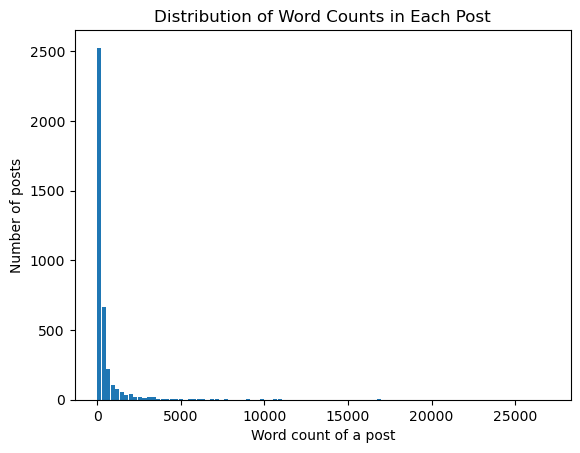

In [10]:
# check the word count distribution of the posts
plt.hist(df_post['length'].sort_values().values, bins=100, rwidth=0.9)
plt.xlabel("Word count of a post")
plt.ylabel("Number of posts")
plt.title("Distribution of Word Counts in Each Post")

In [11]:
# based on the distribution of word counts, we remove samples with word counts >= 6500
df_post = df_post[df_post['length'] < 6500]
df_post.shape

(3874, 5)

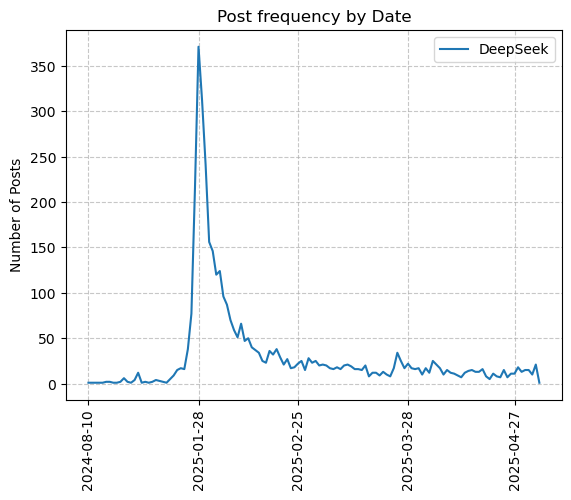

In [12]:
# visualize the post frequency
df_group = df_post.groupby(['date'])
df_bydate = df_group['post'].count().reset_index()

plt.plot(df_bydate['date'], df_bydate['post'], marker=None, linestyle='-', label='DeepSeek')

plt.title('Post frequency by Date')
plt.ylabel('Number of Posts')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# symplify the x labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# rotate tickers
plt.xticks(rotation=90)
plt.show()

**Discussion Q0**: Based on the plot, there's a noticeable peak in the post frequency. Can you explain why this occurred? (hint: Consider relevent developments in AI around that period).

There's a few factors that likely contribute to this peak. First, it's likely that when new version of DeepSeek are launched, people start talking more about it, so there's an surge in interest: users try new models, share results, which creates some sort of network effect. Similarly, news coverages and social media discussion can also drive new users to join the subreddit, which likely amplifies the volume.

# Tasks to complete
In the previous section, we load and clean our Reddit posts before exploring the word counts distribution of the posts. In the following section, we will apply two different unsupervised learning methods to cluster the posts and identify hidden topics, and apply a pretrained supervised learning model to predict public emotions. Recall the difference between supervised and unsupervised learning:
- In supervised learning, we train the model with labeled data, and then apply the model to predict labels for future data;
- In unsupervised learning, we work with unlabled data, aiming to identify hidden patterns or underlying structures of the data.

# Task-1: K-Means Clustering

In this task, you will apply k-means clustering to group the posts into clusters. Specifically, you will:
- Represent each post with a vector (e.g. by using `CountVectorizer`, `TfidfVectorizer`, an OpenAI embedding, or other strategies);
- Fit K-means models for each of a range of possible k's (e.g. `for k in range(2, 10)`), and calculate the `mean_squared_error` (MSE) for each fitted model;
  - Recall that the `MSE` for each cluster is calculated as hte average difference between the cluster center and each data point in the cluster
  - Additionally recall that the `MSE` for the K-means model overall is the average MSE of all the generated clusters
- Visualize how the MSE changes with k (as in the example plot below). Identify **elbow points** fom the plot, and explain the best k in context of the given task.


Here is an example MSE plot.

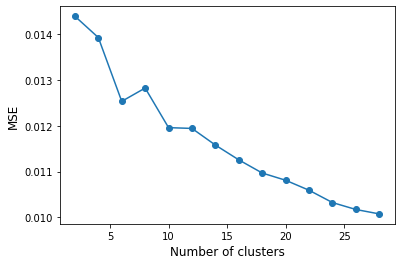

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

In [14]:
text = df_post['post'].astype(str).tolist() # text to list

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X = vectorizer.fit_transform(text) # Fitting vectorizer

In [15]:
mses = [] # MSE list

for k in range(2, 20): #for loop for the kmeans for given k
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_
    
    X_dense = X.toarray()
    se = 0.0
    
    for i in range(X_dense.shape[0]):
        c = centers[labels[i]]
        se += mean_squared_error(X_dense[i], c)
    mses.append(se / X_dense.shape[0])

Text(0, 0.5, 'MSE')

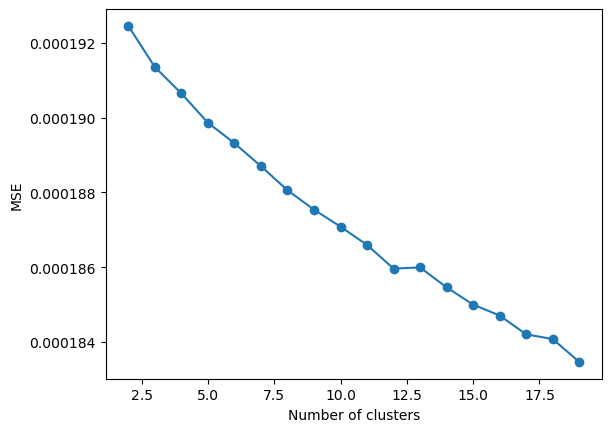

In [16]:
plt.plot(range(2, 20), mses, marker='o') 
plt.xlabel('Number of clusters')
plt.ylabel('MSE')

# Plot of the MSE, very interesting to see this!

**Discussion Q1: Explain the selected k in the context of the given task.** That is, which value of k would you choose based on the produced plot?  Why do you select that k? What does this mean in the context of our Reddit posts?

I would say that there's not a clear elbow point, so I'd pick a small k (~5) to achieve the ideal balance between model simplicity and fit, given that the MSE doesn't change a lot as we increse the number of clusters. This keeps the model reasonable, while capturing most of the reduction of the MSE. 
In the context of the Reddit posts, this mean that we are assuming that there are roughly ~5 main topics in r/DeepSeek, so K-means is splitting posts into these themes. Since there almost infinitely many "topics," it makes sense that MSE keeps going down as we increase K, but we also have to be wary of the tradeoff between simplicity and fit (as mentioned before). 

# Task-2: Sentiment Analysis

In this task, you will conduct sentiment analysis to examine user emotions toward when discussing DeepSeek on Reddit. You can choose to do it with [`vader SentimentIntensityAnalyzer`](https://github.com/cjhutto/vaderSentiment) or [`SamLowe/roberta-base-go_emotions`](https://huggingface.co/SamLowe/roberta-base-go_emotions).


If you choose to apply `vader SentimentIntensityAnalyzer`, then you need to do two broad steps:
1. Preprocess each post:
  - Remove English stopwords;
  - lemmatize each token;
  - Create a joint string of lemmatized tokens;
2. Run the model:
  - Initialize the `SentimentIntensityAnalyzer`;
  - Calculate the `polarity_score` of each processed post;
  - Extract the `compound` field from the `polarity_score` and record them in the new field `vader_sentiment`.

If you choose `SamLowe/roberta-base-go_emotions`, the specific steps are:
1. Apply `transformers.pipeline` to initialize a sentiment classifier from the model `SamLowe/roberta-base-go_emotions`, and apply it to predict emotions (note: the maximum text length the model can process is 514);
2. Record the 28 emotions and corresponding scores in the new field `roberta_multi_scores`;
3. Extract the emotions with a score >= 0.3, and record them in the new field `roberta_emotions`;
4. Save all the emotions in a list, sort the emotions by frequency descending order.



**Regardless of which model you apply, after conducting the sentiment analysis**, please:
1. Plot the sentiment distribution
  - If using the `roberta` model, this can be a bar plot; if using `vader`, this can be a density plot.
2. Visualize the sentiment change over time;
3. Discuss the sentiment distribution and sentiment change over time in the context of the given task.

Examples of all visuals can be seen below.

Example sentiment distribution plot using **Vader**:

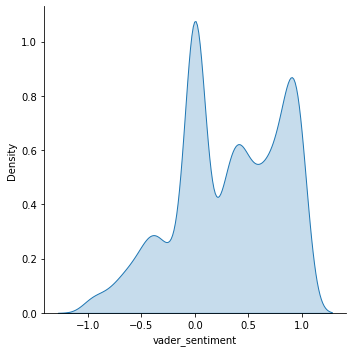

Example sentiment distribution plot using **Roberta**:

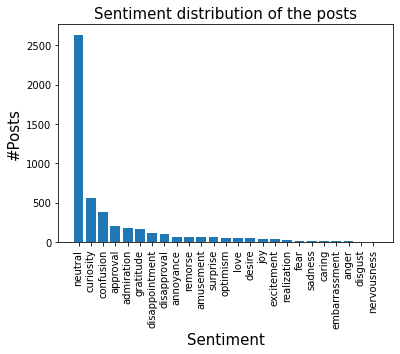

Example plot for **sentiment change over time**:

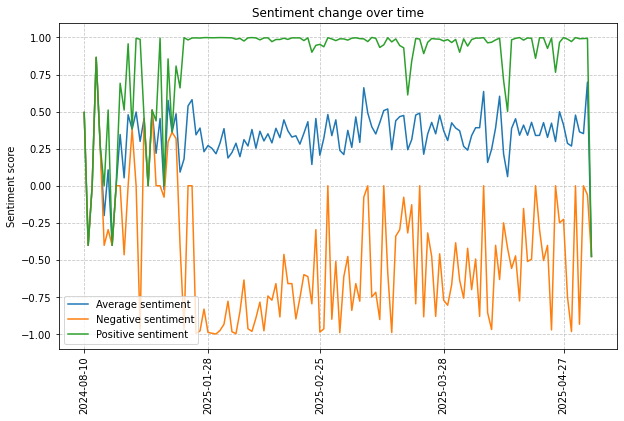

In [17]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Important packages

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Stop_words and lemmatizing

In [19]:
def preprocess_for_vader(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    
    cleaned = []
    for tok in tokens:
        if tok not in stop_words and len(tok) > 2:
            lemma = lemmatizer.lemmatize(tok)
            cleaned.append(lemma)
    
    return " ".join(cleaned)

# Data pre-processing function!

In [20]:
def get_vader_compound(text):
    scores = SentimentIntensityAnalyzer().polarity_scores(text)   
    return scores['compound']

# Gettign the polarity scores

In [21]:
df_post['post_proc'] = df_post['post'].apply(preprocess_for_vader) 

# df after the data pre-processing!

In [22]:
nltk.download('vader_lexicon')

df_post['vader_sentiment'] = df_post['post_proc'].apply(get_vader_compound)
df_post[['post', 'post_proc', 'vader_sentiment']].head()

# Checking the new columns!

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,post,post_proc,vader_sentiment
1,Seriously super factual and level performance,seriously super factual level performance,0.4939
2,anyone tried to get it working in Dev I m gett...,anyone tried get working dev getting error eve...,-0.4019
4,I was chatting through coder but today upon a ...,chatting coder today upon prompt telling refre...,0.0000
5,Its for quick and the code it is fine it even ...,quick code fine even one problem first figure ...,0.8655
6,I use Deep Think ON for first question and OFF...,use deep think first question second forgive s...,0.2732


Text(0, 0.5, 'Density')

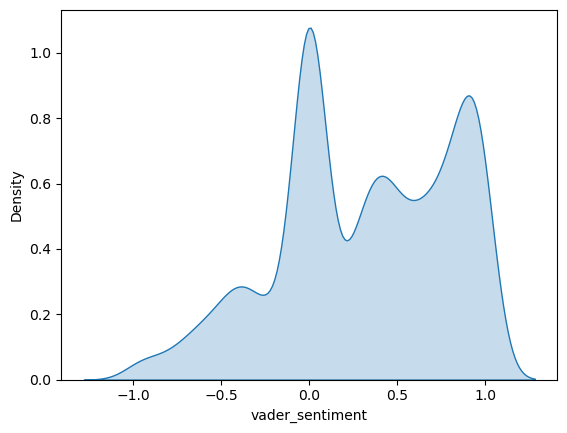

In [24]:
sns.kdeplot(df_post['vader_sentiment'], fill=True)
plt.xlabel('vader_sentiment')
plt.ylabel('Density')

# Density of Vader Sentiment plot

In [25]:
df_post['date'] = pd.to_datetime(df_post['date'])
df_post = df_post.set_index('date')

# Fixing date to appropriate format

Text(0.5, 1.0, 'Sentiment changes over time')

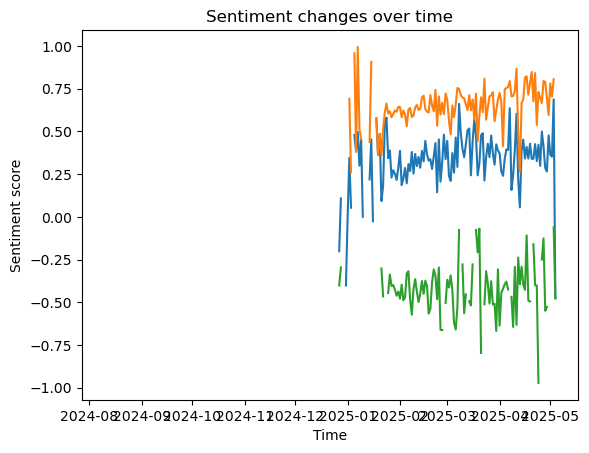

In [26]:
pos = df_post['vader_sentiment'] > 0
neg = df_post['vader_sentiment'] < 0

avg_daily = df_post['vader_sentiment'].resample('D').mean()
pos_daily = df_post.loc[pos, 'vader_sentiment'].resample('D').mean()
neg_daily = df_post.loc[neg, 'vader_sentiment'].resample('D').mean()

plt.plot(avg_daily.index, avg_daily.values, label='Average Sentiment')
plt.plot(pos_daily.index, pos_daily.values, label='Positive Sentiment')
plt.plot(neg_daily.index, neg_daily.values, label='Negative Sentiment')
plt.xlabel('Time')
plt.ylabel('Sentiment score')
plt.title('Sentiment changes over time')

# Sentiment over time.

**Discussion Q2: What do you conclude from the sentiment distribution and sentiment change over time?**

The sentiment distribution seems to be positively skewed, though we have some mild negativity. In the density plot, we see that there's lots of scores above zero and we see a huge peak between 0.5-1.0, while the negative tail is smaller, so most posts are likely neutral/positive.

Average sentiment is usually above 0, meaning that on an average day, the sentiment is likely neutral/positive. The negative sentiment line seems to flutuate more than the positive/average lines. So, the negative sentiment is more explosive, perhaps because of bugs/issues that affect various people on the same day.

The average sentiment seems to be quite constantly above 0, so it's interesting how stable it is, so after launch "euphoria," users seem to get satisfied.

# Task-3: Topic analysis with LDA

In this task, you will perform LDA topic modeling to uncover latent topics on the `r/DeepSeek` subreddit. Specifically, you will:
- Clean the text by removing stopwords, punctuations, and normalize with WordNetLemmatizer;
- Represent each post as a list of tokens;
- Create a dictionary and document-term matrix;
- Fit a LDA model with `num_topics = 3`;
- Print the keywords for each topic;
- Visualize the topic distribution with `pyLDAvis` and interprete the visualization;
- Try different number of topics (e.g., `start=2, limit=40, step=3`), and calculate topic coherence of each model;
- Visualize the change of coherence score with the number of topics and identify the number of topics that gives the best coherence score;
- Re-fit the LDA model with the best number of topics, visualize the topic distribution, and interpete the visualization;

***Note:*** We have example visualizations below, but they are *very* fragile, and will disappear if the "run all" button is clicked in your notebook.

In [27]:
# In order to successfully run LDA, make sure the following packages satisfy the version requirement
# pyLDAvis >= 3.4.0
# pandas < 2.0 # pip install pandas==1.5.3
# gensim >= 4.0

In [28]:
from gensim import corpora
from gensim.models import LdaModel
import string
from pprint import pprint

import pyLDAvis
pyLDAvis.enable_notebook()

import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel
print(pyLDAvis.__version__)

warnings.filterwarnings('ignore', category=DeprecationWarning)

3.4.0


In [29]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english')) # Stop words
lemmatizer = WordNetLemmatizer() # Lemmatizer
punct = set(string.punctuation) # Punctuation

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [30]:
def lda_preprocess(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and tok not in punct and len(tok) > 2]
    return tokens

# pre-processing LDA

In [31]:
texts = df_post['post'].apply(lda_preprocess).tolist()

In [32]:
dictionary = corpora.Dictionary(texts) 
dictionary.filter_extremes(no_below=5, no_above=0.5) # Filtering extremes
corpus = [dictionary.doc2bow(doc) for doc in texts]

In [33]:
lda_3 = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, random_state=42,passes=10, chunksize=100, alpha='auto') 

# Lda Model with n_topics=3

pprint(lda_3.print_topics(num_words=10))

[(0,
  '0.021*"like" + 0.011*"one" + 0.011*"time" + 0.010*"use" + 0.009*"know" + '
  '0.008*"get" + 0.008*"even" + 0.008*"would" + 0.008*"chat" + 0.008*"way"'),
 (1,
  '0.018*"china" + 0.015*"human" + 0.008*"would" + 0.008*"world" + '
  '0.005*"speech" + 0.005*"could" + 0.005*"self" + 0.005*"quantum" + '
  '0.005*"social" + 0.005*"let"'),
 (2,
  '0.024*"model" + 0.012*"data" + 0.008*"open" + 0.007*"user" + '
  '0.007*"information" + 0.006*"tool" + 0.006*"reasoning" + 0.006*"free" + '
  '0.006*"source" + 0.005*"support"')]


In [34]:
pyLDAvis.enable_notebook()
vis_3 = gensimvis.prepare(lda_3, corpus, dictionary)
vis_3   

# Interpreting the visualization: 
# Topic 1: Likely stuff related to everyday usage, so just normal things!
# Topic 2: Topics related to release of new models, things for developers, data, so basically DeepSeek as a model
# Topic 3: Maybe more political approach to DeepSeek, so stuff like geopolitics !

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.252722  0.113505       1        1  47.864201
2     -0.018874 -0.256906       2        1  32.956395
1     -0.233848  0.143401       3        1  19.179403, topic_info=         Term        Freq        Total Category  logprob  loglift
73      model  998.000000   998.000000  Default  30.0000  30.0000
167     china  611.000000   611.000000  Default  29.0000  29.0000
529     human  362.000000   362.000000  Default  28.0000  28.0000
136      data  511.000000   511.000000  Default  27.0000  27.0000
458      know  560.000000   560.000000  Default  26.0000  26.0000
...       ...         ...          ...      ...      ...      ...
193       let  119.185005   492.243071   Topic3  -5.3197   0.2330
385   without   94.314786   370.458762   Topic3  -5.5538   0.2832
2199    clear   76.248656   128.332344   Topic3  -5.7664   1.1307
68       like  112.796236  1537.425947   Topic3  -5.3748  -0.9609
21       time   89.778655   821.176690   Topic3  -5.6031  -0.5621

[185 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
606       1  0.995949      able
275       1  0.204106    access
275       2  0.791431    access
460       3  0.990489       act
38        1  0.995541  actually
...     ...       ...       ...
450       2  0.404356     world
450       3  0.573079     world
94        1  0.558921     would
94        2  0.209595     would
94        3  0.231356     would

[231 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 3, 2])

In [35]:
def compute_coherence_values(texts, corpus, dictionary,
                             start=2, limit=40, step=3):
    models = []
    coherences = []
    for num_topics in range(start, limit + 1, step):
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            chunksize=100,
            alpha='auto'
        )
        cm = CoherenceModel(
            model=lda,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherences.append(cm.get_coherence())
        models.append(lda)
    return models, coherences

# Coherence Values function

In [36]:
models, coherences = compute_coherence_values(texts, corpus, dictionary, start=2, limit=40, step=3)

38

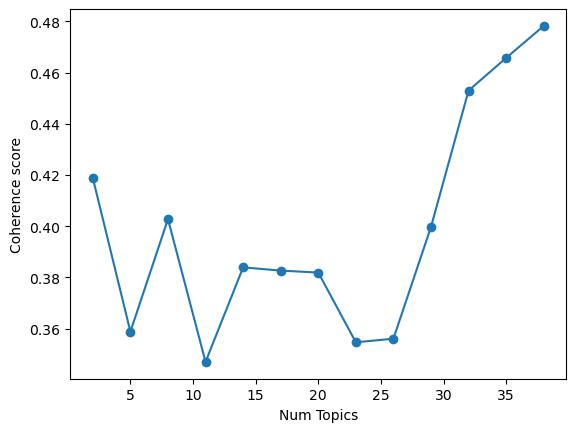

In [37]:
topic_nums = list(range(2, 40 + 1, 3))

plt.plot(topic_nums, coherences, marker='o')
plt.xlabel('Num Topics')
plt.ylabel('Coherence score')

best_idx = int(np.argmax(coherences))
best_num_topics = topic_nums[best_idx]
best_num_topics

In [38]:
# Best coherence score seems to be around k~30 (let's not use k>30 for interpretability reasons)

In [39]:
# Here is the expected topic coherence visualization:

In [45]:
lda_30 = LdaModel(corpus=corpus, id2word=dictionary, num_topics=30, random_state=42,passes=10, chunksize=100, alpha='auto')

pprint(lda_30.print_topics(num_words=10))

[(np.int64(23),
  '0.284*"temperature" + 0.000*"assigned" + 0.000*"manus" + 0.000*"survey" + '
  '0.000*"admix" + 0.000*"strike" + 0.000*"voucher" + 0.000*"transforming" + '
  '0.000*"rock" + 0.000*"regression"'),
 (np.int64(8),
  '0.219*"almost" + 0.140*"decided" + 0.133*"network" + 0.117*"save" + '
  '0.109*"known" + 0.047*"linked" + 0.035*"technology" + 0.000*"assigned" + '
  '0.000*"manus" + 0.000*"survey"'),
 (np.int64(1),
  '0.091*"mode" + 0.089*"letter" + 0.073*"chrome" + 0.066*"strawberry" + '
  '0.054*"wait" + 0.050*"normal" + 0.047*"growth" + 0.046*"standard" + '
  '0.045*"private" + 0.041*"view"'),
 (np.int64(9),
  '0.146*"part" + 0.142*"word" + 0.114*"analysis" + 0.099*"agent" + '
  '0.078*"turn" + 0.068*"result" + 0.065*"note" + 0.044*"written" + '
  '0.037*"third" + 0.034*"breakdown"'),
 (np.int64(6),
  '0.186*"full" + 0.130*"conversation" + 0.102*"file" + 0.080*"python" + '
  '0.073*"root" + 0.073*"reason" + 0.068*"little" + 0.033*"telling" + '
  '0.032*"join" + 0.023*"e

Apply the chosen **best number of topics to re-fit LDA**, visualize & explore it here.

In [47]:
pyLDAvis.enable_notebook()
vis_30 = gensimvis.prepare(lda_30, corpus, dictionary)
vis_30   

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
27    -0.252563 -0.187484       1        1  13.531705
13    -0.161443  0.044372       2        1   8.630357
5     -0.192368 -0.163079       3        1   7.526778
22    -0.107741  0.275720       4        1   6.446219
12    -0.130377  0.031554       5        1   5.997622
28    -0.164353 -0.102876       6        1   5.845762
18    -0.063591 -0.055948       7        1   5.547297
7     -0.056304  0.048963       8        1   4.147648
2     -0.068131  0.279475       9        1   3.740735
21    -0.014723 -0.001307      10        1   3.325935
14    -0.043636  0.064329      11        1   3.289875
3     -0.001815  0.012343      12        1   2.999158
10    -0.002172  0.004578      13        1   2.918824
26     0.045016 -0.015627      14        1   2.577057
15     0.036993  0.070903      15        1   2.252704
11     0.032139 -0.004733      16        1   2.125361
16     0.019655  0.000709      17        1   2.022601
24     0.030011 -0.003455      18        1   1.955476
0      0.050337 -0.017889      19        1   1.953816
19     0.047848  0.000384      20        1   1.947203
17     0.064422 -0.014867      21        1   1.630713
4      0.048936 -0.012695      22        1   1.600166
29     0.058659 -0.012417      23        1   1.484588
25     0.071306 -0.017504      24        1   1.357180
20     0.092109 -0.026256      25        1   1.280441
9      0.089448 -0.006660      26        1   1.164529
6      0.096790 -0.035768      27        1   1.162663
1      0.113168 -0.054134      28        1   1.094777
8      0.178892 -0.052227      29        1   0.409668
23     0.183488 -0.048400      30        1   0.033142, topic_info=        Term         Freq        Total Category  logprob  loglift
102      use  1217.000000  1217.000000  Default  30.0000  30.0000
73     model  1516.000000  1516.000000  Default  29.0000  29.0000
68      like  2171.000000  2171.000000  Default  28.0000  28.0000
94     would  1103.000000  1103.000000  Default  27.0000  27.0000
167    china   848.000000   848.000000  Default  26.0000  26.0000
..       ...          ...          ...      ...      ...      ...
23       try     0.009371   411.937567  Topic30  -8.4098  -2.6789
24      type     0.009371   146.025092  Topic30  -8.4098  -1.6418
25   working     0.009371   255.426906  Topic30  -8.4098  -2.2010
27     coder     0.009371    32.874538  Topic30  -8.4098  -0.1508
28    option     0.009371   100.230165  Topic30  -8.4098  -1.2655

[1138 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
274       4  0.989115     ability
606       5  0.993086        able
35       16  0.982825  absolutely
1196      8  0.931323    academic
174      15  0.940686      accept
...     ...       ...         ...
127      13  0.975873        yeah
451       7  0.993438        year
802       6  0.989654         yes
662      20  0.991619         yet
1051     25  0.983198        zero

[849 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[28, 14, 6, 23, 13, 29, 19, 8, 3, 22, 15, 4, 11, 27, 16, 12, 17, 25, 1, 20, 18, 5, 30, 26, 21, 10, 7, 2, 9, 24])

**Discussion Q3.1: according to the plot, identify the optimal number of topics for the given task, and provide your explaination.**

We see that it keeps increasing as we increase k, so I set k ~30 for simplicity purposes, but we do see that the confidence score keeps increasing. Very interesting! 

Perhaps, we could set k ~ 30, but I chose not to simply for simplicity purposes, as I mentioned.

After running the model, it's quite interesting to see the axis of topics. We see a few very similar topics in the negative y axis and positive X axis, while the other topics are more sparsely distanced in the other axes.

Perhaps we could still split into only 5 topics.

**Discussion Q3.2: Based on the generated plots, characterize the topic distribution. What do the keywords for each topic tell us about the topics? If you had to assign names to the topics, what would they be? Lastly, what do the observed topic distributions tell us about the r/DeepSeek subreddit?**

Again, as I said, we see that the circles that are more sparsely distanced in axes other than the one with positive X, negative Y. In that one, we see that that actually the topics are pretty similar: stuff like server, model, code, output, etc.

The plots suggest that most topics in the subreddit revolve around practical use, setup, and evaluation of the DeepSeek models, with a few smaller clusters about ethics, geopolitics, and broader AI debates.

# Conclusion

In this assignment, we apply two different unsupervised learning methods to cluster the posts (`K-means`) and identify hidden topics (`LDA`), and apply a pretrained supervised learning model to predict public emotions (sentiment classifier).

Through these text analysis methods, we gain insights into users' opinions, usage, and deployment of AI. The identified insights could guide product designers, researchers, and software engineers seeking to find new and relevant use cases for LLMs.

Beyond the example exploration in this jupyter notebook, you can **extend it** in multiple different ways. For example:
- Compare sentiment and topic trends between posts and comments to see if they align or diverge.
- Analyze public perceptions of different AI innovations: examine how discussion topics and sentiments vary across different techniques.
- Explore additional dimensions such as temporal trends or emerging controversies to analyze the data.

Feel free to build on this foundation and uncover deeper insights.